<a href="https://colab.research.google.com/github/Souraka229/-Cardy-Store/blob/main/BENIN_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [14]:
import os

os.chdir('/content/drive/MyDrive/Olympiad IA Benin')
print(os.listdir())

['Test.csv', 'Train.csv', 'SampleSubmission.csv', 'Images.zip']


Deziper le zip

In [15]:
import zipfile

zip_path = "Images.zip"
extract_path = "/content/images"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Nombre d'images :", len(os.listdir(extract_path)))

Nombre d'images : 2


In [16]:
import pandas as pd
import os

# Chemins vers les fichiers CSV sur ton Drive
train_df = pd.read_csv('Train.csv')
test_df = pd.read_csv('Test.csv')
sample_sub = pd.read_csv('SampleSubmission.csv')

print(f"Train: {train_df.shape}")
print(f"Test: {test_df.shape}")
display(train_df.head())

Train: (7000, 2)
Test: (3000, 1)


,Image_ID,Target
0,ID_0073qfb8,0
1,ID_00gy3vH2,1
2,ID_00uB3UFr,0
3,ID_012xZpNw,1
4,ID_014GgMRb,1


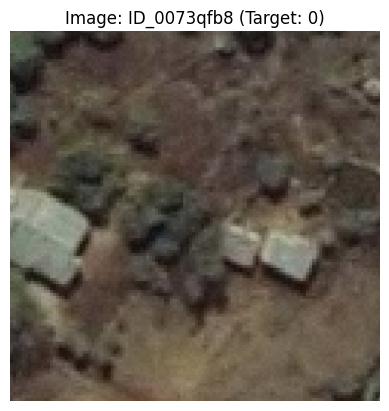

image OK 🔥


In [17]:
from PIL import Image
import matplotlib.pyplot as plt

# Attention : d'après tes logs, les images sont dans /content/images/Images/
# Et le format semble être .tif
img_dir = "/content/images/Images"
img_id = train_df.iloc[0]['Image_ID']
img_path = os.path.join(img_dir, f"{img_id}.tif")

try:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(f"Image: {img_id} (Target: {train_df.iloc[0]['Target']})")
    plt.axis('off')
    plt.show()
    print("image OK 🔥")
except Exception as e:
    print(f"Erreur d'ouverture : {e}")
    print("Vérifie le contenu de /content/images avec os.listdir('/content/images')")

### Préparation du Dataset PyTorch
On définit la classe `RoadDataset` pour gérer le chargement des images `.tif` et les labels.

In [18]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class RoadDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['Image_ID']
        # On force l'extension .tif comme discuté
        img_path = os.path.join(self.img_dir, f"{img_name}.tif")

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        if "Target" in self.df.columns:
            label = self.df.iloc[idx]['Target']
            return image, torch.tensor(label, dtype=torch.float)
        else:
            return image

# Transformations de base
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [19]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['Target'],
    random_state=42
)

train_dataset = RoadDataset(train_data, img_dir, transform=transform)
val_dataset = RoadDataset(val_data, img_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Taille Train: {len(train_dataset)}")
print(f"Taille Val: {len(val_dataset)}")

Taille Train: 5600
Taille Val: 1400


In [20]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# On utilise EfficientNet-B0 pré-entraîné
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)

model = model.to(device)
print(f"Modèle chargé sur : {device}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Modèle chargé sur : cuda


In [21]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

Epoch 1/3 - Loss: 0.4455
Epoch 2/3 - Loss: 0.2643
Epoch 3/3 - Loss: 0.1773


In [22]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['Target'],
    random_state=42
)

train_dataset = RoadDataset(train_data, img_dir, transform=transform)
val_dataset = RoadDataset(val_data, img_dir, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Taille Train: {len(train_dataset)}")
print(f"Taille Val: {len(val_dataset)}")

Taille Train: 5600
Taille Val: 1400


In [23]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Utilisation de EfficientNet-B0
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)

model = model.to(device)
print(f"Modèle chargé sur : {device}")

Modèle chargé sur : cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [24]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}")

Epoch 1/3 - Loss: 0.4345
Epoch 2/3 - Loss: 0.2648
Epoch 3/3 - Loss: 0.1679


### Split des données et DataLoaders
On sépare le dataset en 80% pour l'entraînement et 20% pour la validation, en restant stratifié sur la cible.

In [25]:
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df['Target'],
    random_state=42
)

train_dataset = RoadDataset(train_data, img_dir, transform=transform)
val_dataset = RoadDataset(val_data, img_dir, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Taille Train: {len(train_dataset)}")
print(f"Taille Val: {len(val_dataset)}")

Taille Train: 5600
Taille Val: 1400


### Définition du Modèle
Utilisons `efficientnet_b0` avec une sortie binaire.

In [26]:
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.efficientnet_b0(pretrained=True)
# On adapte la dernière couche pour une classification binaire (1 sortie)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)

model = model.to(device)
print(f"Modèle chargé sur : {device}")

Modèle chargé sur : cuda


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Entraînement
Lançons quelques époques pour voir si la loss diminue.

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

# 1. S'assurer que le modèle est défini
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = models.efficientnet_b0(pretrained=True)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 1)
model = model.to(device)

# 2. Configuration de l'entraînement
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 3

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Progression visible
        if i % 10 == 0:
            print(f"Epoch {epoch+1}/{num_epochs} | Batch {i}/{len(train_loader)} | Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader.dataset)
    print(f"✅ Epoch {epoch+1}/{num_epochs} terminée - Loss: {epoch_loss:.4f}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1/3 | Batch 0/175 | Loss: 0.6964
Epoch 1/3 | Batch 10/175 | Loss: 0.6234
Epoch 1/3 | Batch 20/175 | Loss: 0.4885
Epoch 1/3 | Batch 30/175 | Loss: 0.5485
Epoch 1/3 | Batch 40/175 | Loss: 0.4568
Epoch 1/3 | Batch 50/175 | Loss: 0.4254
Epoch 1/3 | Batch 60/175 | Loss: 0.3591
Epoch 1/3 | Batch 70/175 | Loss: 0.4071
Epoch 1/3 | Batch 80/175 | Loss: 0.5086
Epoch 1/3 | Batch 90/175 | Loss: 0.4002
Epoch 1/3 | Batch 100/175 | Loss: 0.4144
Epoch 1/3 | Batch 110/175 | Loss: 0.2800
Epoch 1/3 | Batch 120/175 | Loss: 0.4124
Epoch 1/3 | Batch 130/175 | Loss: 0.3279
Epoch 1/3 | Batch 140/175 | Loss: 0.2849


In [28]:
from sklearn.metrics import roc_auc_score

model.eval()
val_preds = []
val_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        val_preds.extend(probs.flatten())
        val_labels.extend(labels.numpy().flatten())

auc = roc_auc_score(val_labels, val_preds)
print(f"✅ AUC Validation : {auc:.4f}")

✅ AUC Validation : 0.9403


In [29]:
class RoadDatasetTest(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_id = self.df.loc[idx, 'Image_ID']
        img_path = os.path.join(self.img_dir, img_id + '.tif')
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, img_id

test_dataset = RoadDatasetTest(test_df, img_dir, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)
print(f"Nombre d'images test : {len(test_dataset)}")

Nombre d'images test : 3000


In [31]:
model.eval()
test_preds = []
test_ids = []

print("Début de l'inférence sur le jeu de test...")
with torch.no_grad():
    for images, ids in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.sigmoid(outputs).cpu().numpy()
        test_preds.extend(probs.flatten())
        test_ids.extend(ids)

# Création du DataFrame de soumission
submission = pd.DataFrame({
    'Image_ID': test_ids,
    'Target': test_preds
})

# Sauvegarde sur Drive
submission_path = '/content/drive/MyDrive/Olympiad IA Benin/submission.csv'
submission.to_csv(submission_path, index=False)

print("✅ Fichier sauvegardé !")
display(submission.head(10))

Début de l'inférence sur le jeu de test...
✅ Fichier sauvegardé !


,Image_ID,Target
0,ID_01c6i2wd,0.020214
1,ID_03sPqBLY,0.042587
2,ID_06ZKUQFl,0.999662
3,ID_06gzqIwK,0.002667
4,ID_08kWat36,0.211241
5,ID_09Ek7abU,0.694313
6,ID_0AniuG5s,0.962765
7,ID_0BsPuUz7,0.014813
8,ID_0DSBT3ti,0.108651
9,ID_0FjtVTX3,0.982454
